# Binomial, Trinomial, and Asian Option Pricing

In [3]:
!pip install QuantLib-Python

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm
import QuantLib as ql

# ── Shared colour palette ────────────────────────────────────────────────────
C_INDIGO  = "#4F46E5"
C_ROSE    = "#F43F5E"
C_EMERALD = "#10B981"
C_AMBER   = "#F59E0B"
C_SLATE   = "#94A3B8"

# ── Shared parameters (all questions unless overridden) ──────────────────────
S0    = 100.0   # Initial stock price (ATM)
K     = 100.0   # Strike price
r     = 0.05    # Risk-free rate
sigma = 0.20    # Volatility
T     = 3/12    # Time to expiration (3 months)
n     = 100     # Number of steps

print("Parameters loaded.")
print(f"  S0={S0}, K={K}, r={r}, sigma={sigma}, T={T:.4f}, n={n}")

Parameters loaded.
  S0=100.0, K=100.0, r=0.05, sigma=0.2, T=0.2500, n=100


## European Options - Binomial Tree

## Price an ATM European call and put using a binomial tree

European Call Price (n=100): 4.6050
European Put  Price (n=100): 3.3628


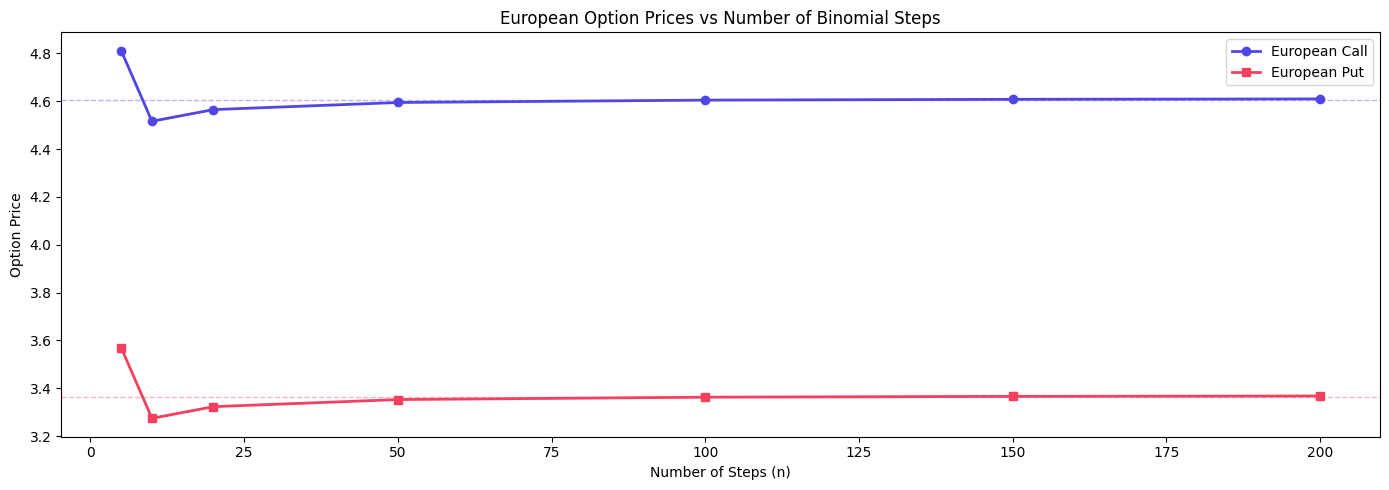

In [4]:
# ── Binomial tree pricer (reusable) ─────────────────────────────────────────
def binomial_price(S0, K, r, sigma, T, n, option_type, style='european'):
    dt = T / n
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1.0 / u
    p  = (np.exp(r * dt) - d) / (u - d)
    df = np.exp(-r * dt)

    # Terminal stock prices (vectorised)
    j     = np.arange(n + 1)
    S_T   = S0 * (u ** j) * (d ** (n - j))

    if option_type == 'call':
        V = np.maximum(S_T - K, 0.0)
    else:
        V = np.maximum(K - S_T, 0.0)

    # Backward induction
    for i in range(n - 1, -1, -1):
        V = df * (p * V[1:i+2] + (1 - p) * V[0:i+1])
        if style == 'american':
            j_i    = np.arange(i + 1)
            S_i    = S0 * (u ** j_i) * (d ** (i - j_i))
            intrinsic = np.maximum(S_i - K, 0.0) if option_type == 'call'                         else np.maximum(K - S_i, 0.0)
            V = np.maximum(V, intrinsic)
    return float(V[0])

def binomial_delta(S0, K, r, sigma, T, n, option_type, style='european'):
    dt  = T / n
    u   = np.exp(sigma * np.sqrt(dt))
    d   = 1.0 / u
    p   = (np.exp(r * dt) - d) / (u - d)
    df  = np.exp(-r * dt)
    j   = np.arange(n + 1)
    S_T = S0 * (u ** j) * (d ** (n - j))
    if option_type == 'call':
        V = np.maximum(S_T - K, 0.0)
    else:
        V = np.maximum(K - S_T, 0.0)
    for i in range(n - 1, -1, -1):
        V = df * (p * V[1:i+2] + (1 - p) * V[0:i+1])
        if style == 'american':
            j_i = np.arange(i + 1)
            S_i = S0 * (u ** j_i) * (d ** (i - j_i))
            intrinsic = np.maximum(S_i - K, 0.0) if option_type == 'call'                         else np.maximum(K - S_i, 0.0)
            V = np.maximum(V, intrinsic)
        if i == 1:
            V1, V0 = V[1], V[0]
            S_u = S0 * u
            S_d = S0 * d
    return (V1 - V0) / (S_u - S_d)

# ── Price European call and put ─────────────────────────────────────────
eur_call = binomial_price(S0, K, r, sigma, T, n, 'call')
eur_put  = binomial_price(S0, K, r, sigma, T, n, 'put')

print(f"European Call Price (n={n}): {eur_call:.4f}")
print(f"European Put  Price (n={n}): {eur_put:.4f}")

# Convergence across step counts
steps = [5, 10, 20, 50, 100, 150, 200]
conv_call = [binomial_price(S0, K, r, sigma, T, m, 'call') for m in steps]
conv_put  = [binomial_price(S0, K, r, sigma, T, m, 'put')  for m in steps]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(steps, conv_call, 'o-', color=C_INDIGO,  linewidth=2, label='European Call')
ax.plot(steps, conv_put,  's-', color=C_ROSE,    linewidth=2, label='European Put')
ax.axhline(eur_call, linestyle='--', color=C_INDIGO,  alpha=0.4, linewidth=1)
ax.axhline(eur_put,  linestyle='--', color=C_ROSE,    alpha=0.4, linewidth=1)
ax.set_title('European Option Prices vs Number of Binomial Steps')
ax.set_xlabel('Number of Steps (n)')
ax.set_ylabel('Option Price')
ax.legend()
plt.tight_layout()
plt.show()

## Compute the Greek Delta for the European call and put at time 0

European Call Delta: 0.5693
European Put  Delta: -0.4307


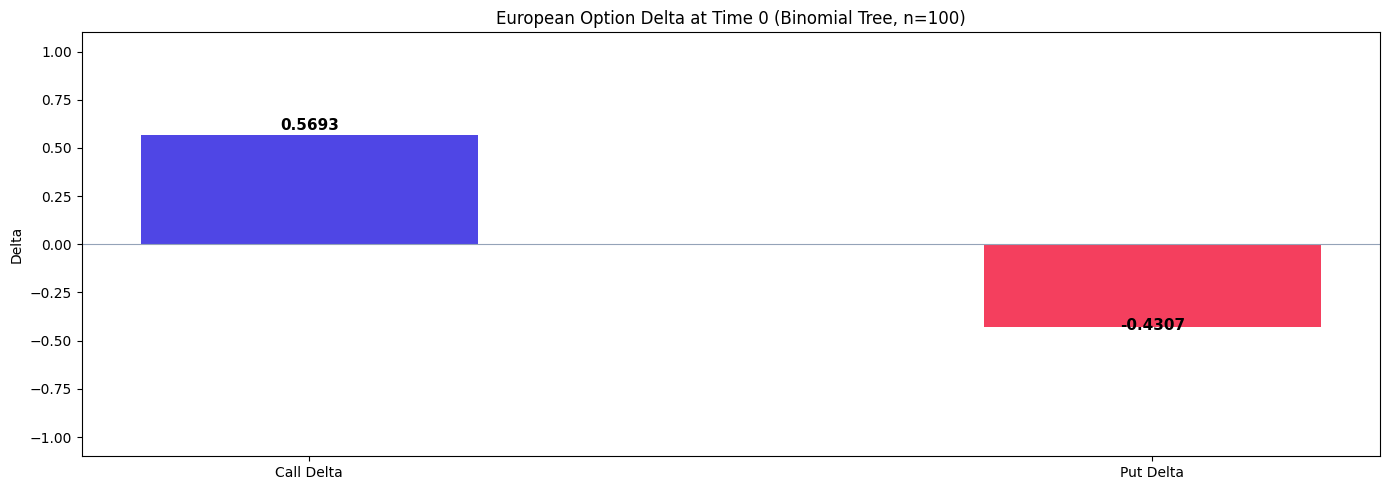

In [5]:
# ── Delta for European call and put ──────────────────────────────────────
delta_call = binomial_delta(S0, K, r, sigma, T, n, 'call')
delta_put  = binomial_delta(S0, K, r, sigma, T, n, 'put')

print(f"European Call Delta: {delta_call:.4f}")
print(f"European Put  Delta: {delta_put:.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(['Call Delta', 'Put Delta'], [delta_call, delta_put],
              color=[C_INDIGO, C_ROSE], width=0.4)
ax.axhline(0, color=C_SLATE, linewidth=0.8)
for bar, val in zip(bars, [delta_call, delta_put]):
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.01 if val >= 0 else -0.03),
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('European Option Delta at Time 0 (Binomial Tree, n=100)')
ax.set_ylabel('Delta')
ax.set_ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

## Compute the sensitivity of option prices to a 5% increase in volatility (20% to 25%)

European Call: 4.6050 -> 5.5860  |  Change: +0.9809
European Put:  3.3628  -> 4.3438   |  Change: +0.9809


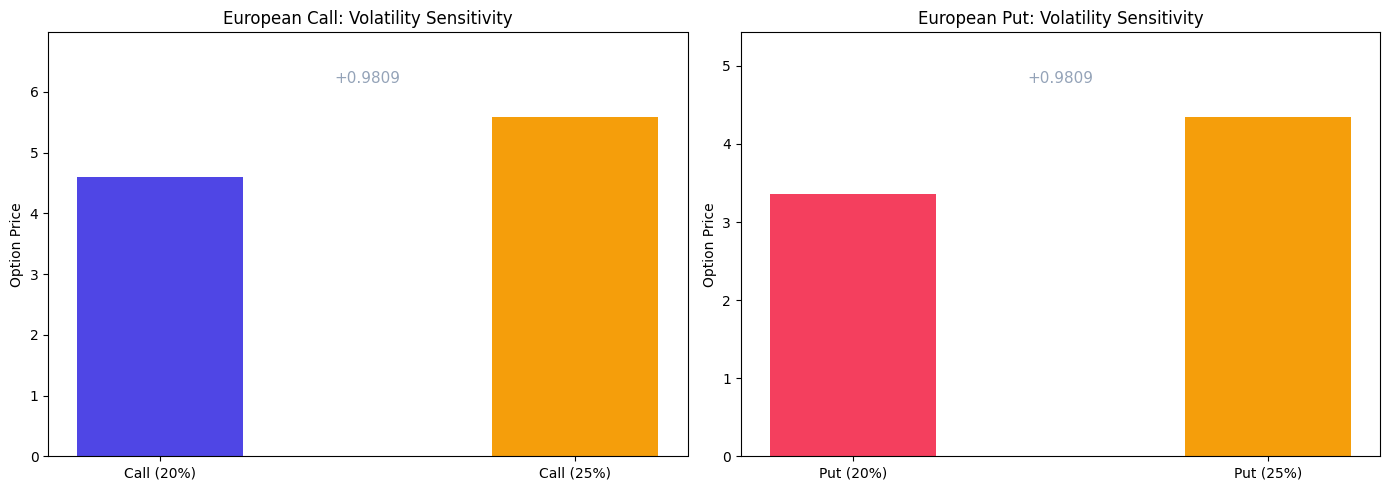

In [7]:
# ── Vega - sensitivity to volatility change ──────────────────────────────
sigma_new = 0.25

eur_call_new = binomial_price(S0, K, r, sigma_new, T, n, 'call')
eur_put_new  = binomial_price(S0, K, r, sigma_new, T, n, 'put')

d_call = eur_call_new - eur_call
d_put  = eur_put_new  - eur_put

print(f"European Call: {eur_call:.4f} -> {eur_call_new:.4f}  |  Change: +{d_call:.4f}")
print(f"European Put:  {eur_put:.4f}  -> {eur_put_new:.4f}   |  Change: +{d_put:.4f}")

labels = ['Call (sigma=20%)', 'Call (sigma=25%)', 'Put (sigma=20%)', 'Put (sigma=25%)']
values = [eur_call, eur_call_new, eur_put, eur_put_new]
colors = [C_INDIGO, C_AMBER, C_ROSE, C_AMBER]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, opt, orig, new_, delta_v, col in zip(
        axes,
        ['Call', 'Put'],
        [eur_call, eur_put],
        [eur_call_new, eur_put_new],
        [d_call, d_put],
        [C_INDIGO, C_ROSE]):
    ax.bar([f'{opt} (20%)', f'{opt} (25%)'], [orig, new_],
           color=[col, C_AMBER], width=0.4)
    ax.set_title(f'European {opt}: Volatility Sensitivity')
    ax.set_ylabel('Option Price')
    ax.set_ylim(0, max(orig, new_) * 1.25)
    ax.annotate(f'+{delta_v:.4f}', xy=(0.5, max(orig, new_) * 1.1),
                ha='center', fontsize=11, color=C_SLATE)

plt.tight_layout()
plt.show()

## American Options - Binomial Tree

## Repeat Q5 for American-style options

American Call Price (n=100): 4.6050
American Put  Price (n=100): 3.4746

Early exercise premium (Call): 0.0000
Early exercise premium (Put):  0.1118


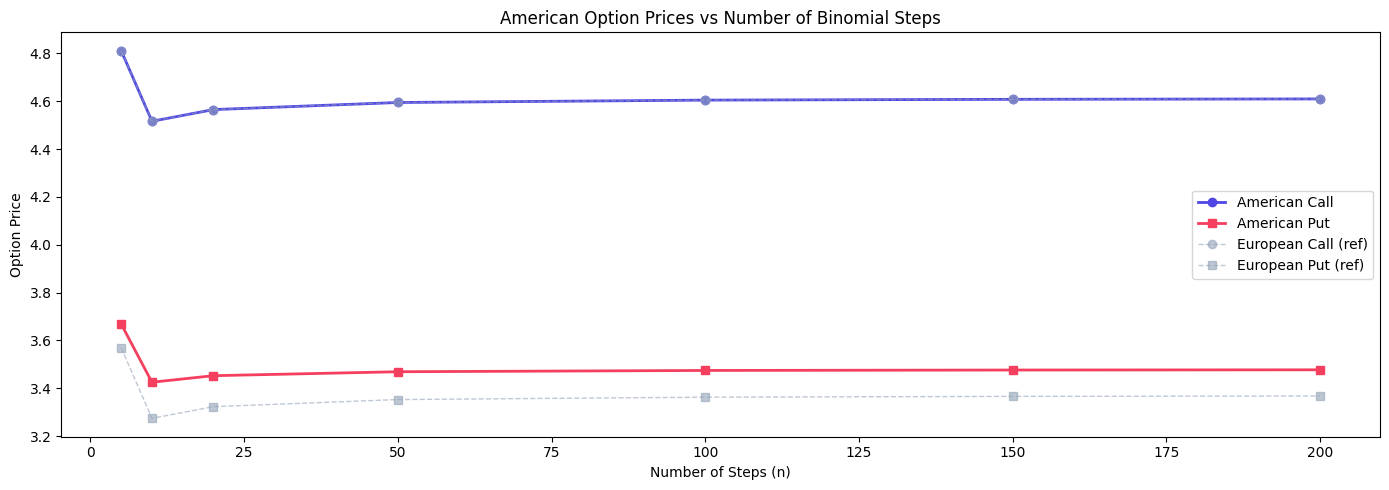

In [8]:
# ── American call and put prices ─────────────────────────────────────────
am_call = binomial_price(S0, K, r, sigma, T, n, 'call', style='american')
am_put  = binomial_price(S0, K, r, sigma, T, n, 'put',  style='american')

print(f"American Call Price (n={n}): {am_call:.4f}")
print(f"American Put  Price (n={n}): {am_put:.4f}")
print()
print(f"Early exercise premium (Call): {am_call - eur_call:.4f}")
print(f"Early exercise premium (Put):  {am_put  - eur_put:.4f}")

steps = [5, 10, 20, 50, 100, 150, 200]
conv_am_call = [binomial_price(S0, K, r, sigma, T, m, 'call', 'american') for m in steps]
conv_am_put  = [binomial_price(S0, K, r, sigma, T, m, 'put',  'american') for m in steps]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(steps, conv_am_call, 'o-', color=C_INDIGO,  linewidth=2, label='American Call')
ax.plot(steps, conv_am_put,  's-', color=C_ROSE,    linewidth=2, label='American Put')
ax.plot(steps, conv_call,    'o--',color=C_SLATE,   linewidth=1, alpha=0.6, label='European Call (ref)')
ax.plot(steps, conv_put,     's--',color=C_SLATE,   linewidth=1, alpha=0.6, label='European Put (ref)')
ax.set_title('American Option Prices vs Number of Binomial Steps')
ax.set_xlabel('Number of Steps (n)')
ax.set_ylabel('Option Price')
ax.legend()
plt.tight_layout()
plt.show()

## Repeat Q6 for American-style options

American Call Delta: 0.5693
American Put  Delta: -0.4498


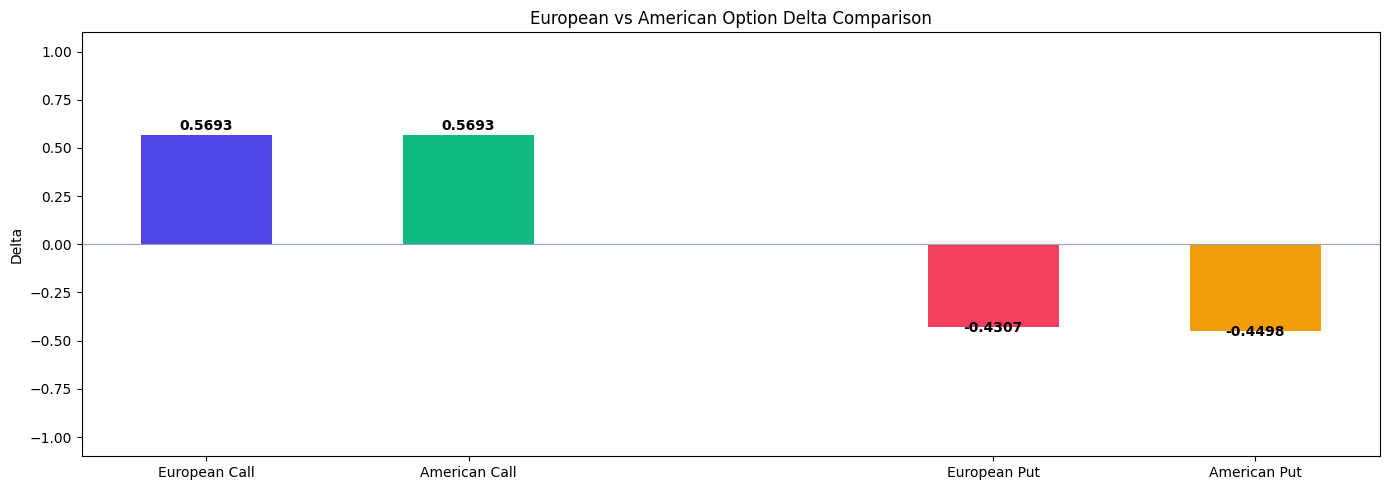

In [9]:
# ── Delta for American options ───────────────────────────────────────────
delta_am_call = binomial_delta(S0, K, r, sigma, T, n, 'call', 'american')
delta_am_put  = binomial_delta(S0, K, r, sigma, T, n, 'put',  'american')

print(f"American Call Delta: {delta_am_call:.4f}")
print(f"American Put  Delta: {delta_am_put:.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
x = np.array([0, 1, 3, 4])
labels = ['European Call', 'American Call', 'European Put', 'American Put']
values = [delta_call, delta_am_call, delta_put, delta_am_put]
colors = [C_INDIGO, C_EMERALD, C_ROSE, C_AMBER]
bars = ax.bar(x, values, color=colors, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.axhline(0, color=C_SLATE, linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.01 if val >= 0 else -0.04),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('European vs American Option Delta Comparison')
ax.set_ylabel('Delta')
ax.set_ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

## Repeat Q7 for American-style options

American Call: 4.6050 -> 5.5860  |  Change: +0.9809
American Put:  3.4746  -> 4.4528   |  Change: +0.9783


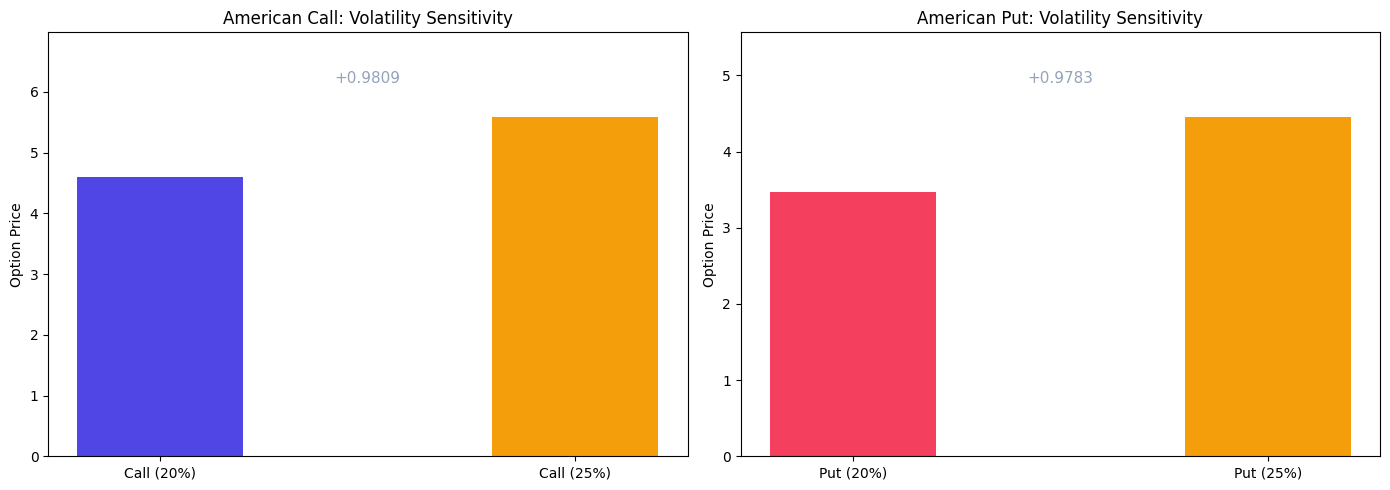

In [11]:
# ── American Vega ────────────────────────────────────────────────────────
am_call_new = binomial_price(S0, K, r, sigma_new, T, n, 'call', 'american')
am_put_new  = binomial_price(S0, K, r, sigma_new, T, n, 'put',  'american')

d_am_call = am_call_new - am_call
d_am_put  = am_put_new  - am_put

print(f"American Call: {am_call:.4f} -> {am_call_new:.4f}  |  Change: +{d_am_call:.4f}")
print(f"American Put:  {am_put:.4f}  -> {am_put_new:.4f}   |  Change: +{d_am_put:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, opt, orig, new_, delta_v, col in zip(
        axes,
        ['Call', 'Put'],
        [am_call, am_put],
        [am_call_new, am_put_new],
        [d_am_call, d_am_put],
        [C_INDIGO, C_ROSE]):
    ax.bar([f'{opt} (20%)', f'{opt} (25%)'], [orig, new_],
           color=[col, C_AMBER], width=0.4)
    ax.set_title(f'American {opt}: Volatility Sensitivity')
    ax.set_ylabel('Option Price')
    ax.set_ylim(0, max(orig, new_) * 1.25)
    ax.annotate(f'+{delta_v:.4f}', xy=(0.5, max(orig, new_) * 1.1),
                ha='center', fontsize=11, color=C_SLATE)

plt.tight_layout()
plt.show()

## European Options - Trinomial Tree

## Price European Call options with different strikes using a trinomial tree

European Call Prices (Trinomial Tree, n=200):
  Deep ITM (K=90): 11.6618
  ITM (K=95): 7.7076
  ATM (K=100): 4.6127
  OTM (K=105): 2.4691
  Deep OTM (K=110): 1.1866


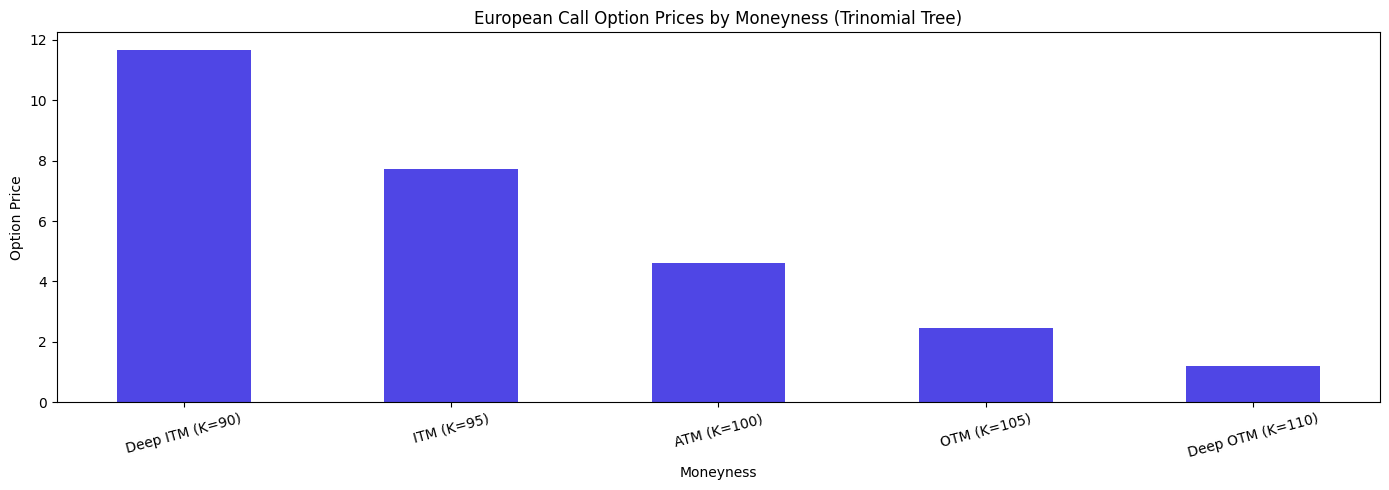

In [12]:
# ── QuantLib trinomial pricer (JarrowRudd binomial engine) ───────────────────
def ql_option_price(S0, K, r, sigma, T, n, option_type, style):
    calendar     = ql.UnitedStates(ql.UnitedStates.Settlement)
    day_counter  = ql.Actual365Fixed()
    calc_date    = ql.Date(5, 8, 2025)
    ql.Settings.instance().evaluationDate = calc_date
    expiry_date  = calc_date + ql.Period(int(T * 365), ql.Days)

    spot_handle  = ql.QuoteHandle(ql.SimpleQuote(S0))
    flat_ts      = ql.YieldTermStructureHandle(
                       ql.FlatForward(calc_date, r, day_counter))
    div_ts       = ql.YieldTermStructureHandle(
                       ql.FlatForward(calc_date, 0.0, day_counter))
    vol_ts       = ql.BlackVolTermStructureHandle(
                       ql.BlackConstantVol(calc_date, calendar, sigma, day_counter))
    process      = ql.BlackScholesMertonProcess(spot_handle, div_ts, flat_ts, vol_ts)

    opt_type = ql.Option.Call if option_type == 'call' else ql.Option.Put
    payoff   = ql.PlainVanillaPayoff(opt_type, K)
    exercise = (ql.EuropeanExercise(expiry_date) if style == 'european'
                else ql.AmericanExercise(calc_date, expiry_date))
    option   = ql.VanillaOption(payoff, exercise)
    engine   = ql.BinomialVanillaEngine(process, 'JarrowRudd', n)
    option.setPricingEngine(engine)
    return round(option.NPV(), 4)

# ── Q15: European Call across moneyness ──────────────────────────────────────
strikes_map = {
    'Deep ITM (K=90)':  90.0,
    'ITM (K=95)':       95.0,
    'ATM (K=100)':     100.0,
    'OTM (K=105)':     105.0,
    'Deep OTM (K=110)':110.0,
}
n_tri = 200

eur_call_tri = {lbl: ql_option_price(S0, K_val, r, sigma, T, n_tri, 'call', 'european')
                for lbl, K_val in strikes_map.items()}

print("European Call Prices (Trinomial Tree, n=200):")
for lbl, price in eur_call_tri.items():
    print(f"  {lbl}: {price:.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(eur_call_tri.keys(), eur_call_tri.values(), color=C_INDIGO, width=0.5)
ax.set_title('European Call Option Prices by Moneyness (Trinomial Tree)')
ax.set_xlabel('Moneyness')
ax.set_ylabel('Option Price')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## Repeat Q15 for European Put options

European Put Prices (Trinomial Tree, n=200):
  Deep ITM (K=90): 0.5469
  ITM (K=95): 1.5307
  ATM (K=100): 3.3738
  OTM (K=105): 6.1683
  Deep OTM (K=110): 9.8238


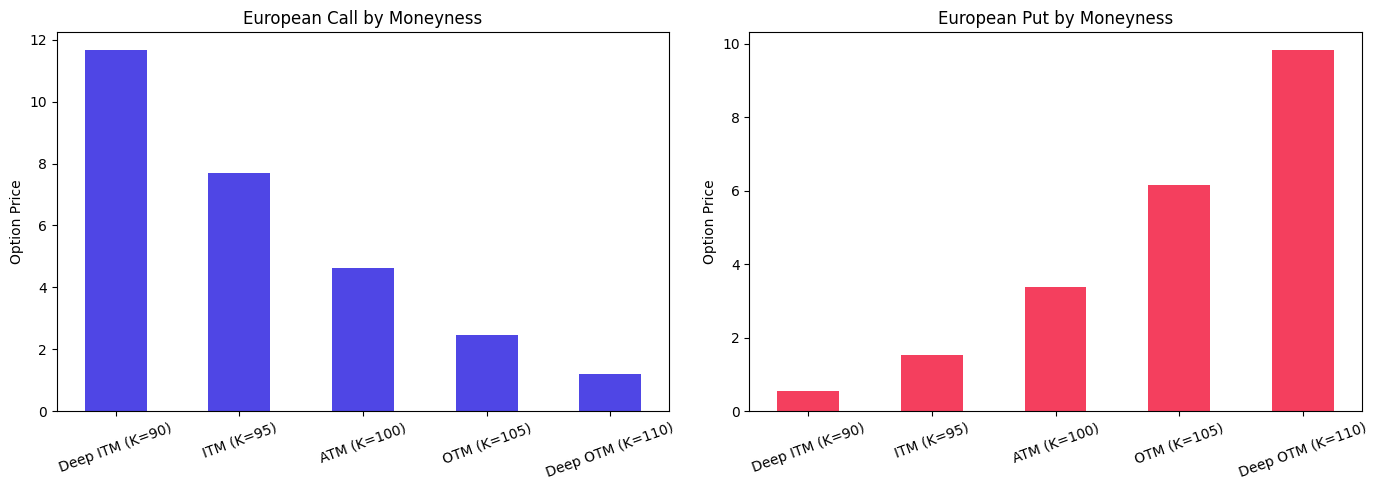

In [13]:
# ── European Put across moneyness ───────────────────────────────────────
eur_put_tri = {lbl: ql_option_price(S0, K_val, r, sigma, T, n_tri, 'put', 'european')
               for lbl, K_val in strikes_map.items()}

print("European Put Prices (Trinomial Tree, n=200):")
for lbl, price in eur_put_tri.items():
    print(f"  {lbl}: {price:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(eur_call_tri.keys(), eur_call_tri.values(), color=C_INDIGO, width=0.5)
axes[0].set_title('European Call by Moneyness')
axes[0].set_ylabel('Option Price')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(eur_put_tri.keys(), eur_put_tri.values(), color=C_ROSE, width=0.5)
axes[1].set_title('European Put by Moneyness')
axes[1].set_ylabel('Option Price')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## American Options - Trinomial Tree

## Repeat Q15 for American Call options

In [14]:
# ── American Call across moneyness ──────────────────────────────────────
am_call_tri = {lbl: ql_option_price(S0, K_val, r, sigma, T, n_tri, 'call', 'american')
               for lbl, K_val in strikes_map.items()}

print("American Call Prices (Trinomial Tree, n=200):")
for lbl, price in am_call_tri.items():
    print(f"  {lbl}: {price:.4f}")

American Call Prices (Trinomial Tree, n=200):
  Deep ITM (K=90): 11.6618
  ITM (K=95): 7.7076
  ATM (K=100): 4.6127
  OTM (K=105): 2.4691
  Deep OTM (K=110): 1.1866


## Repeat Q16 for American Put options

American Put Prices (Trinomial Tree, n=200):
  Deep ITM (K=90): 0.5583
  ITM (K=95): 1.5690
  ATM (K=100): 3.4806
  OTM (K=105): 6.4192
  Deep OTM (K=110): 10.3297


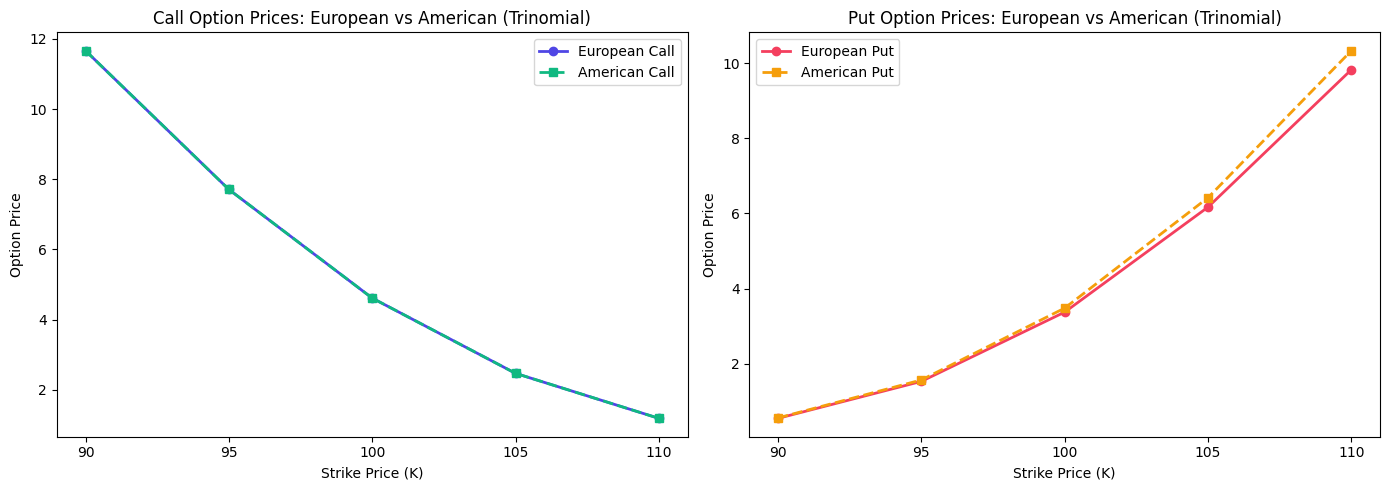

In [15]:
# ── American Put across moneyness ───────────────────────────────────────
am_put_tri = {lbl: ql_option_price(S0, K_val, r, sigma, T, n_tri, 'put', 'american')
              for lbl, K_val in strikes_map.items()}

print("American Put Prices (Trinomial Tree, n=200):")
for lbl, price in am_put_tri.items():
    print(f"  {lbl}: {price:.4f}")

# ── Summary: European vs American across moneyness ───────────────────────────
K_vals   = list(strikes_map.values())
labels_x = [str(int(k)) for k in K_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_vals, list(eur_call_tri.values()), 'o-', color=C_INDIGO,  linewidth=2, label='European Call')
axes[0].plot(K_vals, list(am_call_tri.values()),  's--',color=C_EMERALD, linewidth=2, label='American Call')
axes[0].set_title('Call Option Prices: European vs American (Trinomial)')
axes[0].set_xlabel('Strike Price (K)')
axes[0].set_ylabel('Option Price')
axes[0].set_xticks(K_vals); axes[0].set_xticklabels(labels_x)
axes[0].legend()

axes[1].plot(K_vals, list(eur_put_tri.values()), 'o-', color=C_ROSE,  linewidth=2, label='European Put')
axes[1].plot(K_vals, list(am_put_tri.values()),  's--',color=C_AMBER, linewidth=2, label='American Put')
axes[1].set_title('Put Option Prices: European vs American (Trinomial)')
axes[1].set_xlabel('Strike Price (K)')
axes[1].set_ylabel('Option Price')
axes[1].set_xticks(K_vals); axes[1].set_xticklabels(labels_x)
axes[1].legend()

plt.tight_layout()
plt.show()

## Dynamic Delta Hedging

Asian ATM Put Price (MC + control variate, 100k sims): 7.9983
Final Stock Price:   187.10
      Path Average Price:  180.94
      Option Payoff:       1.06
      Hedging Error (P&L): 24.1784


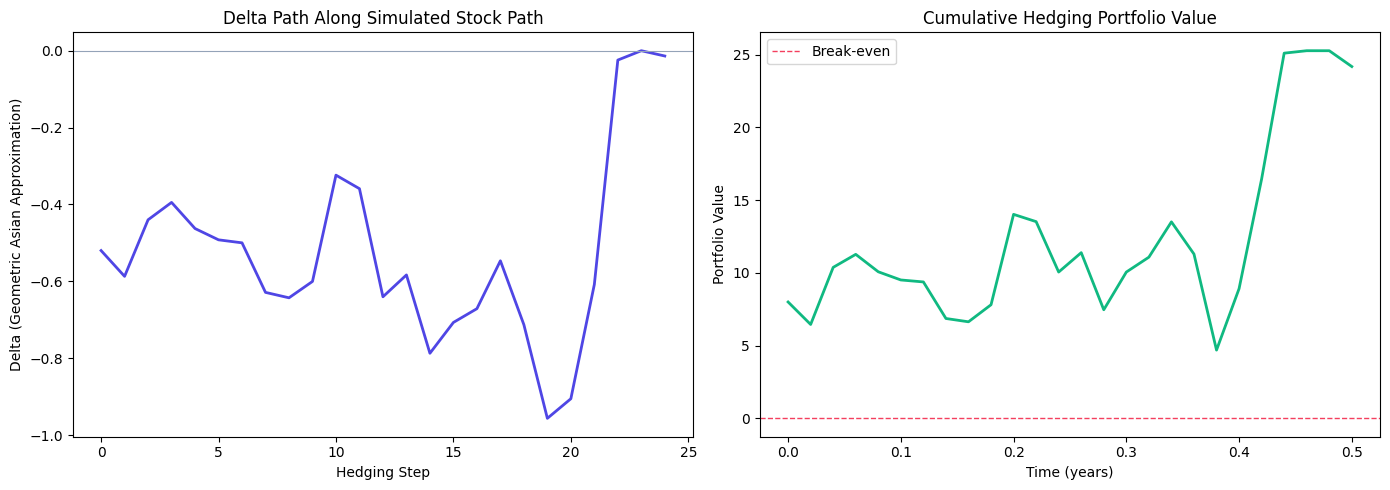

In [16]:
# ── Geometric Asian option + dynamic delta hedging ───────────────────
# Parameters for Asian option
S0_h  = 180.0
K_h   = 182.0
r_h   = 0.02
sigma_h = 0.25
T_h   = 0.5
N_h   = 25       # Number of averaging / hedging steps

np.random.seed(42)

# ── Geometric Asian option: closed-form price and delta ──────────────────────
def geo_asian_price(S0, K, T, r, sigma, N, option_type):
    sig_a = sigma * np.sqrt((2*N + 1) / (6*(N + 1)))
    r_a   = r - sigma**2/2 + sig_a**2/2
    d1 = (np.log(S0/K) + (r_a + sig_a**2/2)*T) / (sig_a * np.sqrt(T))
    d2 = d1 - sig_a * np.sqrt(T)
    if option_type == 'call':
        return S0 * np.exp((r_a - r)*T) * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return K * np.exp(-r*T) * norm.cdf(-d2) - S0 * np.exp((r_a - r)*T) * norm.cdf(-d1)

def geo_asian_delta(S0, K, T, r, sigma, N, option_type):
    sig_a = sigma * np.sqrt((2*N + 1) / (6*(N + 1)))
    r_a   = r - sigma**2/2 + sig_a**2/2
    d1 = (np.log(S0/K) + (r_a + sig_a**2/2)*T) / (sig_a * np.sqrt(T))
    return np.exp((r_a - r)*T) * (norm.cdf(d1) if option_type == 'call'
                                  else norm.cdf(d1) - 1)

# ── Monte Carlo: Arithmetic Asian with geometric control variate ─────────────
def arith_asian_mc_cv(S0, K, T, r, sigma, N, M, option_type, seed=42):
    np.random.seed(seed)
    dt      = T / N
    Z       = np.random.standard_normal((M, N))
    log_S   = np.cumsum((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z, axis=1)
    log_S   = np.log(S0) + log_S
    prices  = np.exp(log_S)

    arith_avg = prices.mean(axis=1)
    geo_avg   = np.exp(log_S.mean(axis=1))

    if option_type == 'call':
        pf_a = np.maximum(arith_avg - K, 0)
        pf_g = np.maximum(geo_avg   - K, 0)
    else:
        pf_a = np.maximum(K - arith_avg, 0)
        pf_g = np.maximum(K - geo_avg,   0)

    geo_ref = geo_asian_price(S0, K, T, r, sigma, N, option_type)
    cov_    = np.cov(pf_a, pf_g)[0, 1]
    var_    = np.var(pf_g)
    b       = cov_ / var_ if var_ > 1e-12 else 0

    mc_price = np.exp(-r*T) * (pf_a.mean() - b * (pf_g.mean() - geo_ref))
    return mc_price

asian_put_price = arith_asian_mc_cv(S0_h, K_h, T_h, r_h, sigma_h, N_h, 100_000, 'put')
print(f"Asian ATM Put Price (MC + control variate, 100k sims): {asian_put_price:.4f}")

# ── Delta hedging simulation ────────────────────────────────────────────
dt_h  = T_h / N_h
path  = [S0_h]
for _ in range(N_h):
    z = np.random.standard_normal()
    path.append(path[-1] * np.exp((r_h - 0.5*sigma_h**2)*dt_h + sigma_h*np.sqrt(dt_h)*z))

premium     = arith_asian_mc_cv(S0_h, K_h, T_h, r_h, sigma_h, N_h, 10_000, 'put')
cash        = premium    # Seller receives premium
shares_held = 0.0
pnl         = []
deltas      = []

for i in range(N_h):
    S_i   = path[i]
    ttm   = T_h - i * dt_h
    delta = geo_asian_delta(S_i, K_h, ttm, r_h, sigma_h, N_h - i, 'put')
    target_shares = -delta
    d_shares = target_shares - shares_held
    cash    -= d_shares * S_i
    shares_held = target_shares
    deltas.append(delta)
    pnl.append(cash + shares_held * S_i)

# Settle at maturity
final_S   = path[-1]
avg_price = np.mean(path[1:])
payoff    = max(K_h - avg_price, 0)
cash     += shares_held * final_S
cash     -= payoff
pnl.append(cash)

print(f"Final Stock Price:   {final_S:.2f}")
print(f"      Path Average Price:  {avg_price:.2f}")
print(f"      Option Payoff:       {payoff:.2f}")
print(f"      Hedging Error (P&L): {cash:.4f}")

# ── Visualise hedging P&L and delta path ─────────────────────────────────
time_axis = np.linspace(0, T_h, N_h + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(N_h), deltas, color=C_INDIGO, linewidth=2)
axes[0].axhline(0, color=C_SLATE, linewidth=0.8)
axes[0].set_title('Delta Path Along Simulated Stock Path')
axes[0].set_xlabel('Hedging Step')
axes[0].set_ylabel('Delta (Geometric Asian Approximation)')

axes[1].plot(time_axis, pnl, color=C_EMERALD, linewidth=2)
axes[1].axhline(0, color=C_ROSE, linewidth=1, linestyle='--', label='Break-even')
axes[1].set_title('Cumulative Hedging Portfolio Value')
axes[1].set_xlabel('Time (years)')
axes[1].set_ylabel('Portfolio Value')
axes[1].legend()

plt.tight_layout()
plt.show()